**Table of contents**<a id='toc0_'></a>    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# Importing libraries and setting filepaths:

In [273]:
file_path=r'data\cleaned\cleaned_dataset_v4.csv'
##%pip install matplotlib seaborn plotly
#%pip install nbformat>=4.2.0
#%pip install dash
#%pip install scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from dash import Dash, dcc, html, Output, Input
import plotly.figure_factory as ff
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
import itertools
df=pd.read_csv(file_path)

In [274]:
df.head()

,url,property_id,price,rooms,area,state,facades_number,is_furnished,has_terrace,has_garden,...,terrain_width_roadside,g_score,p_score,cadastral_income,vat,maintenance_cost,property_subtype,postal_code,locality,property_type
0,https://immovlan.be/en/detail/apartment/for-sa...,rbu69315,269000.0,1.0,51.0,NaN,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,No,NaN,apartment,2600,berchem,Apartment
1,https://immovlan.be/en/detail/apartment/for-sa...,rbu69316,299000.0,2.0,79.0,Normal,2.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,No,NaN,apartment,2050,antwerp,Apartment
2,https://immovlan.be/en/detail/apartment/for-sa...,rbu68996,359000.0,3.0,110.0,NaN,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,No,NaN,apartment,2610,wilrijk,Apartment
3,https://immovlan.be/en/detail/apartment/for-sa...,rbu69309,239000.0,2.0,84.0,Normal,2.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,No,NaN,apartment,2060,antwerp,Apartment
4,https://immovlan.be/en/detail/apartment/for-sa...,rbu69307,189000.0,2.0,80.0,Normal,2.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,No,NaN,apartment,2610,wilrijk,Apartment


# Number of columns and rows:

In [275]:
total_entries = len(df)
total_columns = len(df.columns)
print(f"The dataset contains ({total_entries}) entries in ({total_columns}) columns")

The dataset contains (23320) entries in (66) columns


# Percentage of filled columns:

In [276]:
filled=df.count()
filled=filled/total_entries
filled=filled*100
filled=filled.sort_values(ascending=False)
import plotly.express as px
fig = px.bar(filled)
fig.add_hline(y=50, line_dash="dash", line_color="red")
fig.add_hline(y=70, line_dash="dash", line_color="orange")
fig.add_hline(y=90, line_dash="dash", line_color="green")
fig.update_layout(xaxis_tickangle=-45, yaxis_title="Filled proportion (%)")
fig.show()

Creating columns for price per m2 & logarithm of the price, as these will be useful for further calculations

In [277]:
df = df[df["area"] >= 15] #cleaning the unrealistic surfaces - there were some with surface set as 1m2. Setting to 15 as it's within the average minimum surface area 
df= df[df["price"] >=70_000] # cleaning unrealistic prices

df['price_per_m2']=df['price']/df['area']
df['log10_price'] = np.log10(df['price'])
df['log10_price_per_m2']=np.log10(df['price_per_m2'])

Distribution of prices and surfaces of properties:

In [278]:
from scipy.stats import gaussian_kde


def plot_distribution(df,column_name, bins=100, xlim=None):
    data=[df[column_name].dropna()]
    labels=[column_name]

    fig = ff.create_distplot(
        data, labels,
        bin_size=(df[column_name].max() - df[column_name].min()) / bins,
        show_rug=False)
    if xlim:
        fig.update_xaxes(range=xlim)
    fig.update_layout(
        title=f"Distribution of {column_name}",
        xaxis_title=column_name,
        yaxis_title="Density",
        bargap=0.05
    )
    fig.show()




In [279]:
plot_distribution(df,'price',bins=2000,xlim=(0,3_000_000))

In [280]:
plot_distribution(df, "area", bins=50000,xlim=(0,3000))

The KDE curve is stretched because of a very long tail. Using log scale to stabilise this. The reason of right-skewness will be analysed later on.

In [281]:
df["log10_area"] = np.log10(df["area"])
plot_distribution(df, "log10_area", bins=200, xlim=(1,3))


In [282]:
plot_distribution(df, "price_per_m2", bins=3000,xlim=(200,10000))

The distributions look quite right-skewed. Below are some metrics to quantify this skewness


In [283]:
skew_value = skew(df["price"].dropna())
print("Skewness:", skew_value)


Skewness: 11.10929777579365


The skewness value of more than 1 is already considered highly right-skewed. A value of 11 is so extreme that the approach needs to be modified

# Outliers:

In [284]:
def boxplot_grid(df, columns, rows=3, cols=3, xlim_dict=None):
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 2*rows))
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        data = df[col].dropna()

        # Empty column protection
        if len(data) == 0:
            ax.set_title(col + " (no data)")
            ax.axis("off")
            continue

        sns.boxplot(x=data, ax=ax, orient="h")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")

        # Priority 1: custom xlim if provided
        if xlim_dict and col in xlim_dict:
            ax.set_xlim(xlim_dict[col])

        # Priority 2: auto xlim if no custom xlim
        else:
            q1, q99 = data.quantile([0.01, 0.99])
            ax.set_xlim(q1, q99)

    # Turn off unused subplots
    for ax in axes[len(columns):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


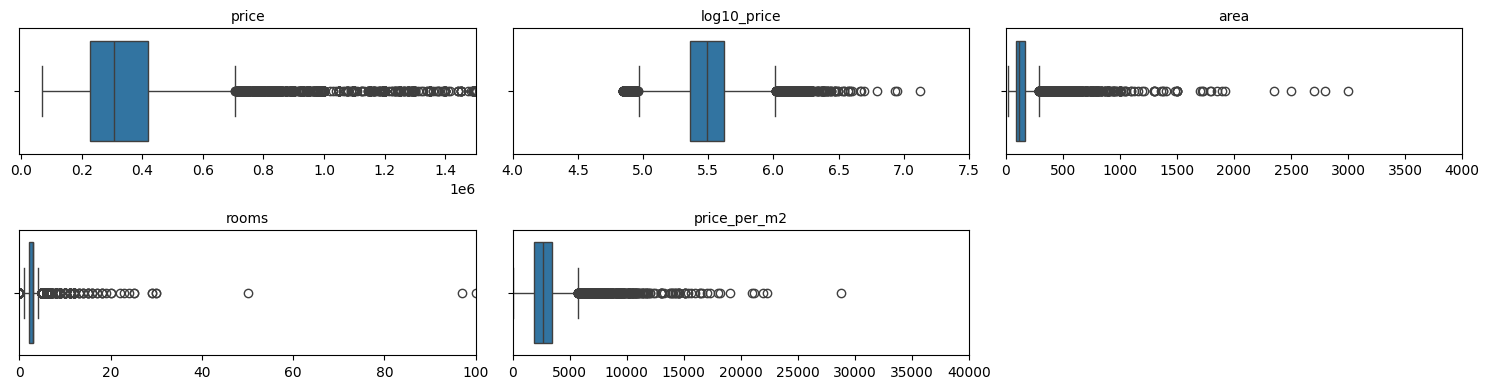

In [290]:
cols_to_plot = ["price", 'log10_price',"area", "rooms", "price_per_m2", ]
custom_xlim = {
    "price": (-5000, 1_500_000),
    "area": (0, 4000),
    "rooms": (0,100),
    'log10_price': (4,7.5),
    'price_per_m2': (0,40000)
}
boxplot_grid(df, cols_to_plot,rows=2,cols=3,xlim_dict=custom_xlim)

Most outliers are coming from the right side of the x axis 

There is a group of highly expensive properties. Those groups are often entire buildings with 1000s of apartaments inside that are sold in one package, as well as highly luxurious properties (villas etc) Therefore we need to separate them from the main group.

In [ ]:

df_clustered= df[["area", "rooms",'price']].dropna()
# scale variables (important!)
scaler = StandardScaler()
X = scaler.fit_transform(df_clustered)

# cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42)
df_clustered["cluster"] = kmeans.fit_predict(X)
df = df.merge(df_clustered["cluster"], left_index=True, right_index=True, how="left")

In [ ]:

df["property_class"] = df["cluster"].map({0: "luxury", 1: "residential"})


Counting how many properties were separated to each cluster:

In [ ]:

df["property_class"].value_counts(normalize=True)*100


property_class
residential    90.687098
luxury          9.312902
Name: proportion, dtype: float64

Visualising clusters:

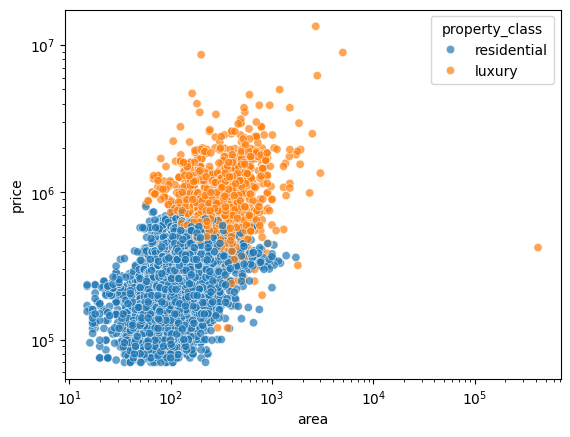

In [ ]:
sns.scatterplot(data=df, x="area", y="price", hue="property_class", alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.show()


In [ ]:
df.groupby("property_class")[["area","rooms","price","price_per_m2"]].median()


,area,rooms,price,price_per_m2
property_class,,,,
luxury,269.0,4.0,769500.0,2815.735472
residential,114.0,2.0,296000.0,2675.675676


We see that despite the luxury class having ~3x the median price of the property, the price of the square meter remains close.

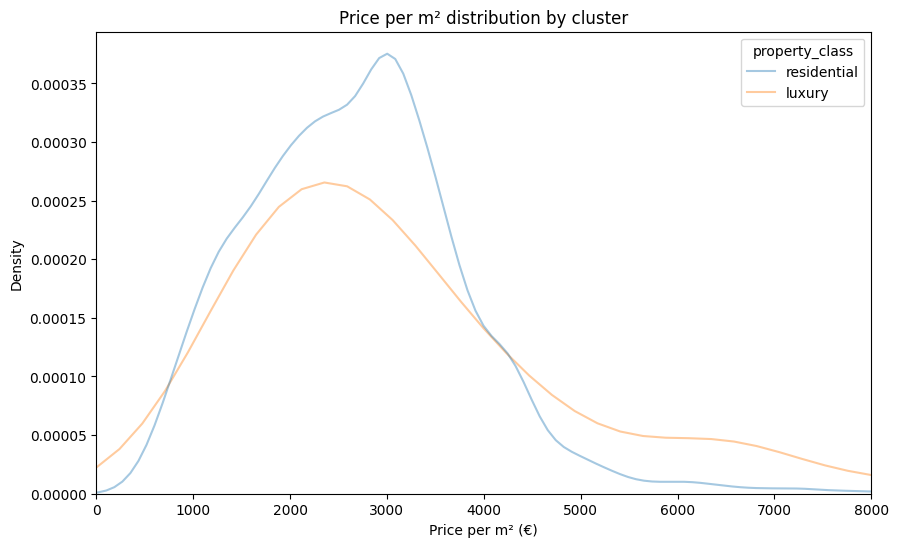

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="price_per_m2", hue="property_class", fill=False, common_norm=False, alpha=0.4)
plt.xlim(0,8000)  # adjust as needed
plt.title("Price per m² distribution by cluster")
plt.xlabel("Price per m² (€)")
plt.show()

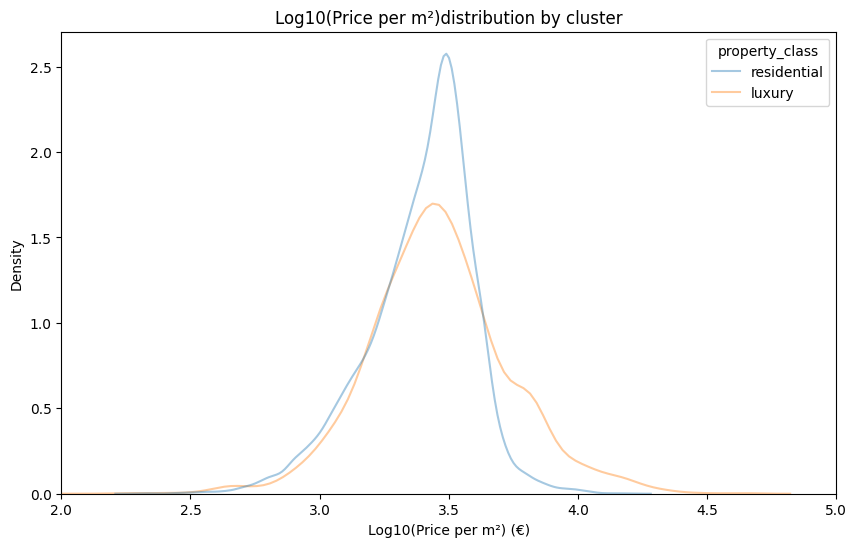

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="log10_price_per_m2", hue="property_class", fill=False, common_norm=False, alpha=0.4)
plt.xlim(2,5)  # adjust as needed
plt.title("Log10(Price per m²)distribution by cluster")
plt.xlabel("Log10(Price per m²) (€)")
plt.show()

In [ ]:
def plot_kde(df,column_name,xlim=None):
    data = [df[column_name].dropna()]
    labels = [column_name]
    kde=gaussian_kde(data)
    x = np.linspace(0,8000,num=2000)
    y = kde(x)
    plt.plot(x, y, color=color, label="KDE")


def calculate_fwhm(data,column,xmin=0,xmax=8000,points=3000):

    data=data[column].dropna().values
    kde = gaussian_kde(data)
    #creating x-grid for KDE evaluation
    x = np.linspace(xmin,xmax,points)
    y = kde(x)

    
    y_max=np.max(y)
    half_max = np.max(y) / 2
    idx = np.where(y >= half_max)[0]
    right= x[idx[-1]]
    left= x[idx[0]]
    fwhm=  right-left
    return x,y, y_max, half_max, left,right, fwhm


In [ ]:
df_residential_cluster = df[df["cluster"] == 1]
df_luxury_cluster=df[df["cluster"]==0]



calculate_fwhm(df,column='price_per_m2')
calculate_fwhm(df_residential_cluster,column='price_per_m2')
calculate_fwhm(df_luxury_cluster,column='price_per_m2')


(array([0.00000000e+00, 2.66755585e+00, 5.33511170e+00, ...,
        7.99466489e+03, 7.99733244e+03, 8.00000000e+03], shape=(3000,)),
 array([2.23700717e-05, 2.25129910e-05, 2.26565990e-05, ...,
        1.60049499e-05, 1.59710728e-05, 1.59373256e-05], shape=(3000,)),
 np.float64(0.00026556049116484103),
 np.float64(0.00013278024558242051),
 np.float64(1029.6765588529508),
 np.float64(4086.695565188396),
 np.float64(3057.019006335445))

In [ ]:
def plot_kde_with_fwhm(df, value_col, xmin=0, xmax=8000,
                       cluster_col="property_class",
                       title=""):


    # Automatic distinct colors (infinite cycle)
    color_cycle = itertools.cycle(plt.cm.tab10.colors)

    plt.figure(figsize=(10,6))

    for cl in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cl]

        res = calculate_fwhm(subset, column=value_col, xmin=xmin, xmax=xmax)
        if res is None:
            continue

        x, y, y_max, half_max, left, right, fwhm = res
        color = next(color_cycle)

        peak_idx = y.argmax()
        peak_x = x[peak_idx]
        peak_y = y[peak_idx]

        plt.plot(x, y, color=color, label=f"{cluster_col}={cl}")

        # Peak marker
        plt.scatter([peak_x], [peak_y], color="red", s=60)
        
        # Peak label
        plt.annotate(
            f"Peak = {peak_x:.0f} ",
            xy=(peak_x, peak_y),
            xytext=(peak_x, peak_y * 1.12),
            arrowprops=dict(arrowstyle="->", color=color),
            ha="center",
            fontsize=10,
            color=color
        )

        # Half max line
        plt.hlines(half_max, left, right, colors=color, linestyles="dotted", alpha=0.5)

        # FWHM annotation
        mid = (left + right) / 2
        plt.text(
            mid,
            half_max * 1.05,
            f"FWHM = {fwhm:.0f} ",
            ha="center",
            color=color,
            fontsize=10
        )

    plt.xlim(xmin, xmax)
    plt.title(title or f"KDE + FWHM for {value_col}",x=0.65)
    plt.xlabel(value_col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


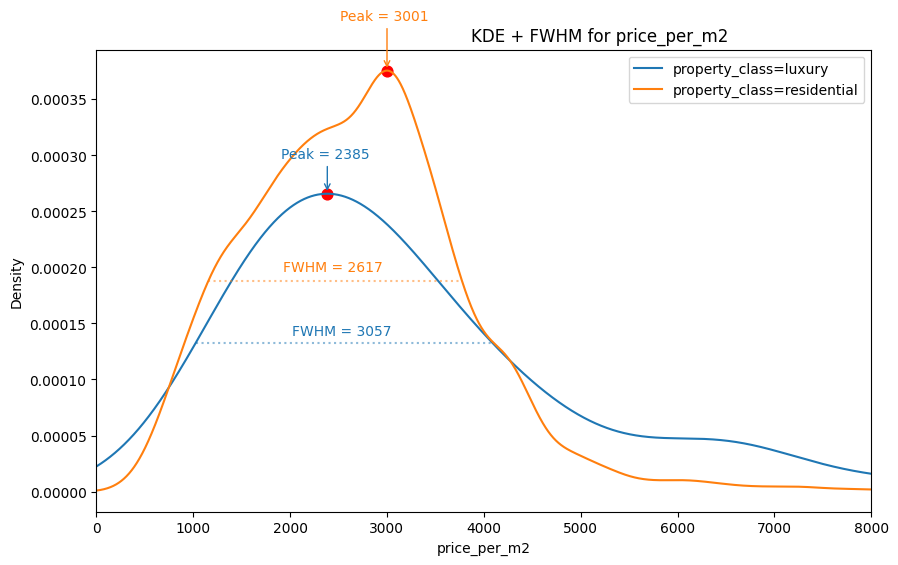

In [ ]:
plot_kde_with_fwhm(df,value_col='price_per_m2')

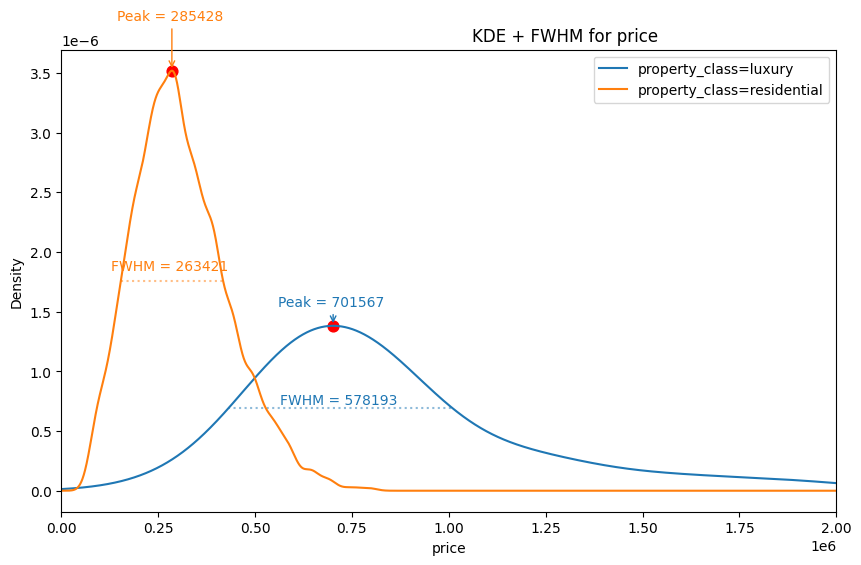

In [ ]:
plot_kde_with_fwhm(df,value_col='price',xmin=0,xmax=2_000_000)

Metrics on skewness:

price_per_m2

In [ ]:
skew_value = skew(df["price_per_m2"].dropna())
print("Skewness of the global dataset:", skew_value)


Skewness of the global dataset: 3.7204387185795897


Residential cluster:

In [ ]:
skew_value = skew(df_residential_cluster["price_per_m2"].dropna())
print("Skewness of the residential dataset:")
print(skew_value)


Skewness of the residential dataset:
1.3997130276327536


Luxury cluster:


In [ ]:
skew_value = skew(df_luxury_cluster["price_per_m2"].dropna())
print("Skewness of the luxury dataset:")
print(skew_value)


Skewness of the luxury dataset:
3.951747993683755


Price:

Global

In [ ]:
skew_value = skew(df["price"].dropna())
print("Skewness of the global dataset:", skew_value)


Skewness of the global dataset: 11.10929777579365


Residential:

In [ ]:
skew_value = skew(df_residential_cluster["price"].dropna())
print("Skewness of the residential dataset:", skew_value)
print(skew_value)


Skewness of the residential dataset: 0.6018969227919756
0.6018969227919756


Luxury

In [ ]:
skew_value = skew(df_luxury_cluster["price"].dropna())
print("Skewness of the luxury dataset:")
print(skew_value)


Skewness of the luxury dataset:
7.900936709309194


Area:


Global:

In [ ]:
skew_value = skew(df["area"].dropna())
print("Skewness of the global dataset:", skew_value)


Skewness of the global dataset: 143.11252884024398


Residential:

In [ ]:
skew_value = skew(df_residential_cluster["area"].dropna())
print("Skewness of the residential dataset:")
print(skew_value)


Skewness of the residential dataset:
4.3506716496368565


Luxury:

In [ ]:
skew_value = skew(df_luxury_cluster["area"].dropna())
print("Skewness of the luxury dataset:")
print(skew_value)


Skewness of the luxury dataset:
43.32467218995299


The above values as well as information on peak positions and FWHMs lead to a fundamental conclusion: for analysis and for further creating the ML model, big and luxurious properties need to be considered separate, as most of the skewness comes, as suspected, from these properties.
The "regular" residential segment, although improved, remains highly skewed. This suggests the need for a more advanced strategy (for example, splitting the data into more clusters, using a different clustering algorithm or clustering by different features).
This will be tackled in detail the next phase of the project.